In [7]:
import gymnasium as gym
import ale_py

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

from pyvirtualdisplay import Display

%matplotlib inline

In [8]:
env_name = "ALE/MsPacman-v5"

env = gym.make(env_name, render_mode="rgb_array")

A.L.E: Arcade Learning Environment (version 0.12.0+0706845)
[Powered by Stella]


### Exploring the environment

In [9]:
env.action_space

Discrete(9)

In [10]:
list(range(env.action_space.n))

[0, 1, 2, 3, 4, 5, 6, 7, 8]

In [11]:
for i in range(10):
    print(str(i) + ": ", env.action_space.sample())

0:  1
1:  3
2:  8
3:  8
4:  0
5:  2
6:  8
7:  8
8:  4
9:  7


Action space is a (9,) vector then. With discrete actions being lit up.

In [12]:
env.observation_space

Box(0, 255, (210, 160, 3), uint8)

So the observation space is 210x160 3-channel array with values between 0-255 in RGB array mode

In [13]:
obs, info = env.reset()

In [14]:
info

{'lives': 3, 'episode_frame_number': 0, 'frame_number': 0}

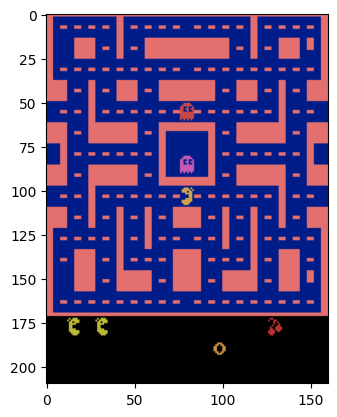

In [15]:
plt.imshow(obs)

### Reshaping the observation

2 0.0 False False {'lives': 3, 'episode_frame_number': 4, 'frame_number': 4}
(65, 84)


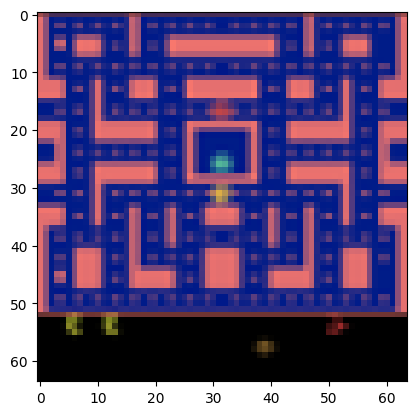

In [16]:
from PIL import Image
env_64 = gym.wrappers.ResizeObservation(env, (84, 65))

# obs, info  = env_64.reset()

sample_act = env.action_space.sample()
obs, reward, truncated, terminated, info = env_64.step(sample_act)
print(sample_act, reward, truncated, terminated, info)

obs = Image.fromarray(obs)
plt.imshow(obs.resize((64, 64)))        # Resizing keeping the frame aspect ratio

print(obs.size)

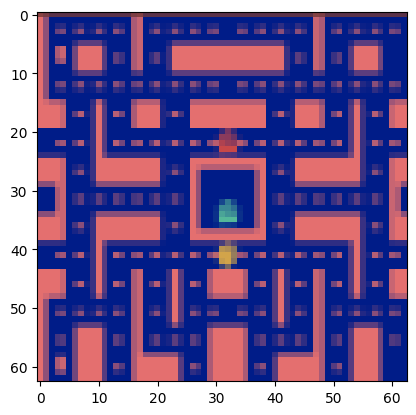

In [17]:
# Cropping the observation
obs = obs.crop((0, 0, 63, 63))
plt.imshow(obs)

### Recording and Evaluating rollouts

In [18]:
num_eval_eps = 5

env_rec = gym.wrappers.RecordVideo(
    env, 
    video_folder="./videos/examples/",
    name_prefix="test-video"
)
env_rec = gym.wrappers.RecordEpisodeStatistics(
    env_rec, buffer_length=num_eval_eps
)

rewards_hist = []

/home/utkarsh/active_projects/world-models/.venv/lib/python3.10/site-packages/gymnasium/wrappers/rendering.py:292: UserWarning: WARN: Overwriting existing videos at /home/utkarsh/active_projects/world-models/videos/examples folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [19]:
for ep_num in range(num_eval_eps):
    obs, info = env_rec.reset()
    ep_reward = 0
    step_count = 0
    
    while True:
        action = env_rec.action_space.sample()
        obs, reward, terminated, truncated, info= env_rec.step(action)
        
        ep_reward += float(reward)
        step_count += 1
        
        if (terminated or truncated): break
    
    print(f"Episode {ep_num + 1}: {step_count} steps, reward = {ep_reward}")

env_rec.close()

# Print summary statistics
print(f'\nEvaluation Summary:')
print(f'Episode durations: {list(env_rec.time_queue)}')
print(f'Episode rewards: {list(env_rec.return_queue)}')
print(f'Episode lengths: {list(env_rec.length_queue)}')

# Calculate some useful metrics
avg_reward = np.mean(env_rec.return_queue)
avg_length = np.sum(env_rec.length_queue)
std_reward = np.std(env_rec.return_queue)

print(f'\nAverage reward: {avg_reward:.2f} ± {std_reward:.2f}')
print(f'Average episode length: {avg_length:.1f} steps')
print(f'Success rate: {sum(1 for r in env_rec.return_queue if r > 0) / len(env_rec.return_queue):.1%}')


Episode 1: 721 steps, reward = 390.0
Episode 2: 537 steps, reward = 260.0
Episode 3: 555 steps, reward = 320.0
Episode 4: 451 steps, reward = 170.0
Episode 5: 839 steps, reward = 320.0

Evaluation Summary:
Episode durations: [0.246193, 0.17889, 0.17016, 0.134319, 0.238225]
Episode rewards: [390.0, 260.0, 320.0, 170.0, 320.0]
Episode lengths: [721, 537, 555, 451, 839]

Average reward: 292.00 ± 73.59
Average episode length: 3103.0 steps
Success rate: 100.0%


### Checking `env.reset()` multiple times

In [20]:
env = gym.make(env_name, render_mode="rgb_array")

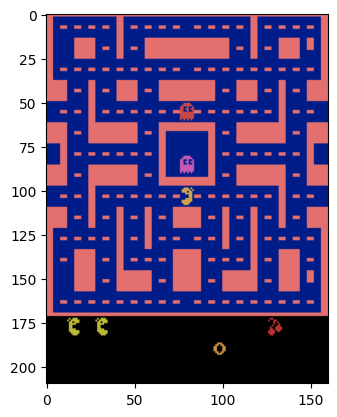

In [21]:
obs, info = env.reset()
plt.imshow(obs)

## Checking the NoOp on Reset

Whenever I'm visualizing MsPacman, it seems that for the couple of frames, even though there's a control signal being sent, there are no changes in the actual environment. I need to probe it first.

In [22]:
env_rec = gym.wrappers.RecordVideo(
    env, 
    video_folder="./videos/examples/",
    name_prefix="test-video-trial"
)
env_rec = gym.wrappers.RecordEpisodeStatistics(env_rec)

rewards_hist = []

In [23]:
obs, info = env_rec.reset()
prev_obs = obs.copy()

frame_idx = 0
for frame_idx in range(65):
    action = env_rec.action_space.sample()
    obs, reward, terminated, truncated, info = env_rec.step(action)
    # diff = np.abs(obs.astype(int) - prev_obs.astype(int)).sum()
    # print(frame_idx, diff, action, info.get("lives"))
    print(frame_idx, action, info.get("lives"))
    prev_obs = obs.copy()
    
    if (terminated or truncated): break

env_rec.close()

0 2 3
1 1 3
2 5 3
3 2 3
4 2 3
5 5 3
6 8 3
7 7 3
8 6 3
9 6 3
10 0 3
11 8 3
12 0 3
13 4 3
14 5 3
15 4 3
16 8 3
17 0 3
18 5 3
19 5 3
20 0 3
21 5 3
22 3 3
23 2 3
24 7 3
25 6 3
26 3 3
27 8 3
28 3 3
29 8 3
30 8 3
31 0 3
32 2 3
33 3 3
34 5 3
35 8 3
36 5 3
37 5 3
38 1 3
39 4 3
40 3 3
41 7 3
42 2 3
43 3 3
44 8 3
45 6 3
46 6 3
47 3 3
48 0 3
49 7 3
50 6 3
51 5 3
52 5 3
53 0 3
54 5 3
55 6 3
56 8 3
57 6 3
58 6 3
59 6 3
60 8 3
61 7 3
62 2 3
63 4 3
64 1 3


## Comparing different interpolation strategies for resizing according to the preprocessing pipeline

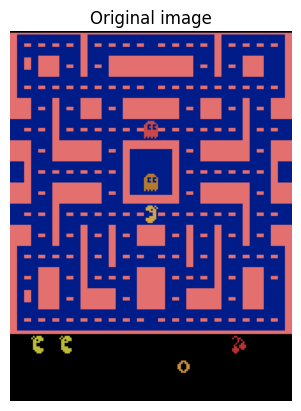

In [24]:
frame, _, _, _, _ = env.step(env.action_space.sample())

plt.imshow(frame)
plt.title("Original image")
plt.axis("off")
plt.show()

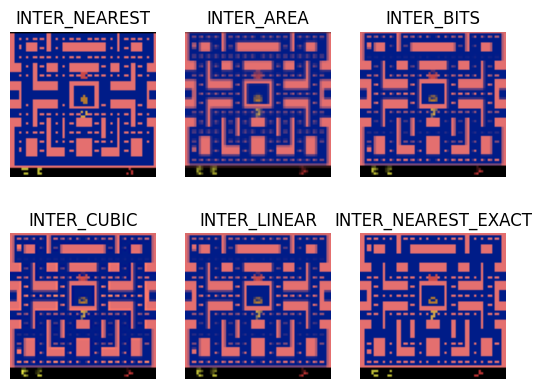

In [25]:
import cv2

# Preprocessing pipeline for the frame
frame = frame[:186, :160, :]

# Comparing different interpolation strats
strats = [cv2.INTER_NEAREST, cv2.INTER_AREA, cv2.INTER_BITS, cv2.INTER_CUBIC, cv2.INTER_LINEAR, cv2.INTER_NEAREST_EXACT]
names = ["INTER_NEAREST", "INTER_AREA", "INTER_BITS", "INTER_CUBIC", "INTER_LINEAR", "INTER_NEAREST_EXACT"]

fig, axs = plt.subplots(2, 3)

for ax, strat, name in zip(axs.flat, strats, names):
    ax.imshow(cv2.resize(frame, (64, 64), interpolation=strat))
    ax.set_title(str(name))
    ax.axis("off")
    
plt.show()

## Getting the background

In [46]:
import torch
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
from utils.data_utils import RNNDataset

def collate_fn(batch):
    # batch = [(obs[0], acts[0]), ..., (obs[i], acts[i])]
    observations = [ep[0] for ep in batch]
    actions = [ep[1] for ep in batch]
    
    lengths = torch.tensor([len(obs) for obs in observations])
    
    observations = pad_sequence(observations, batch_first=True)
    actions = pad_sequence(actions, batch_first=True)
    
    # Return padded sequence, along with original sequnence length
    return observations, actions, lengths

dl = DataLoader(RNNDataset("./data/"), batch_size=4, shuffle=True, collate_fn=collate_fn)

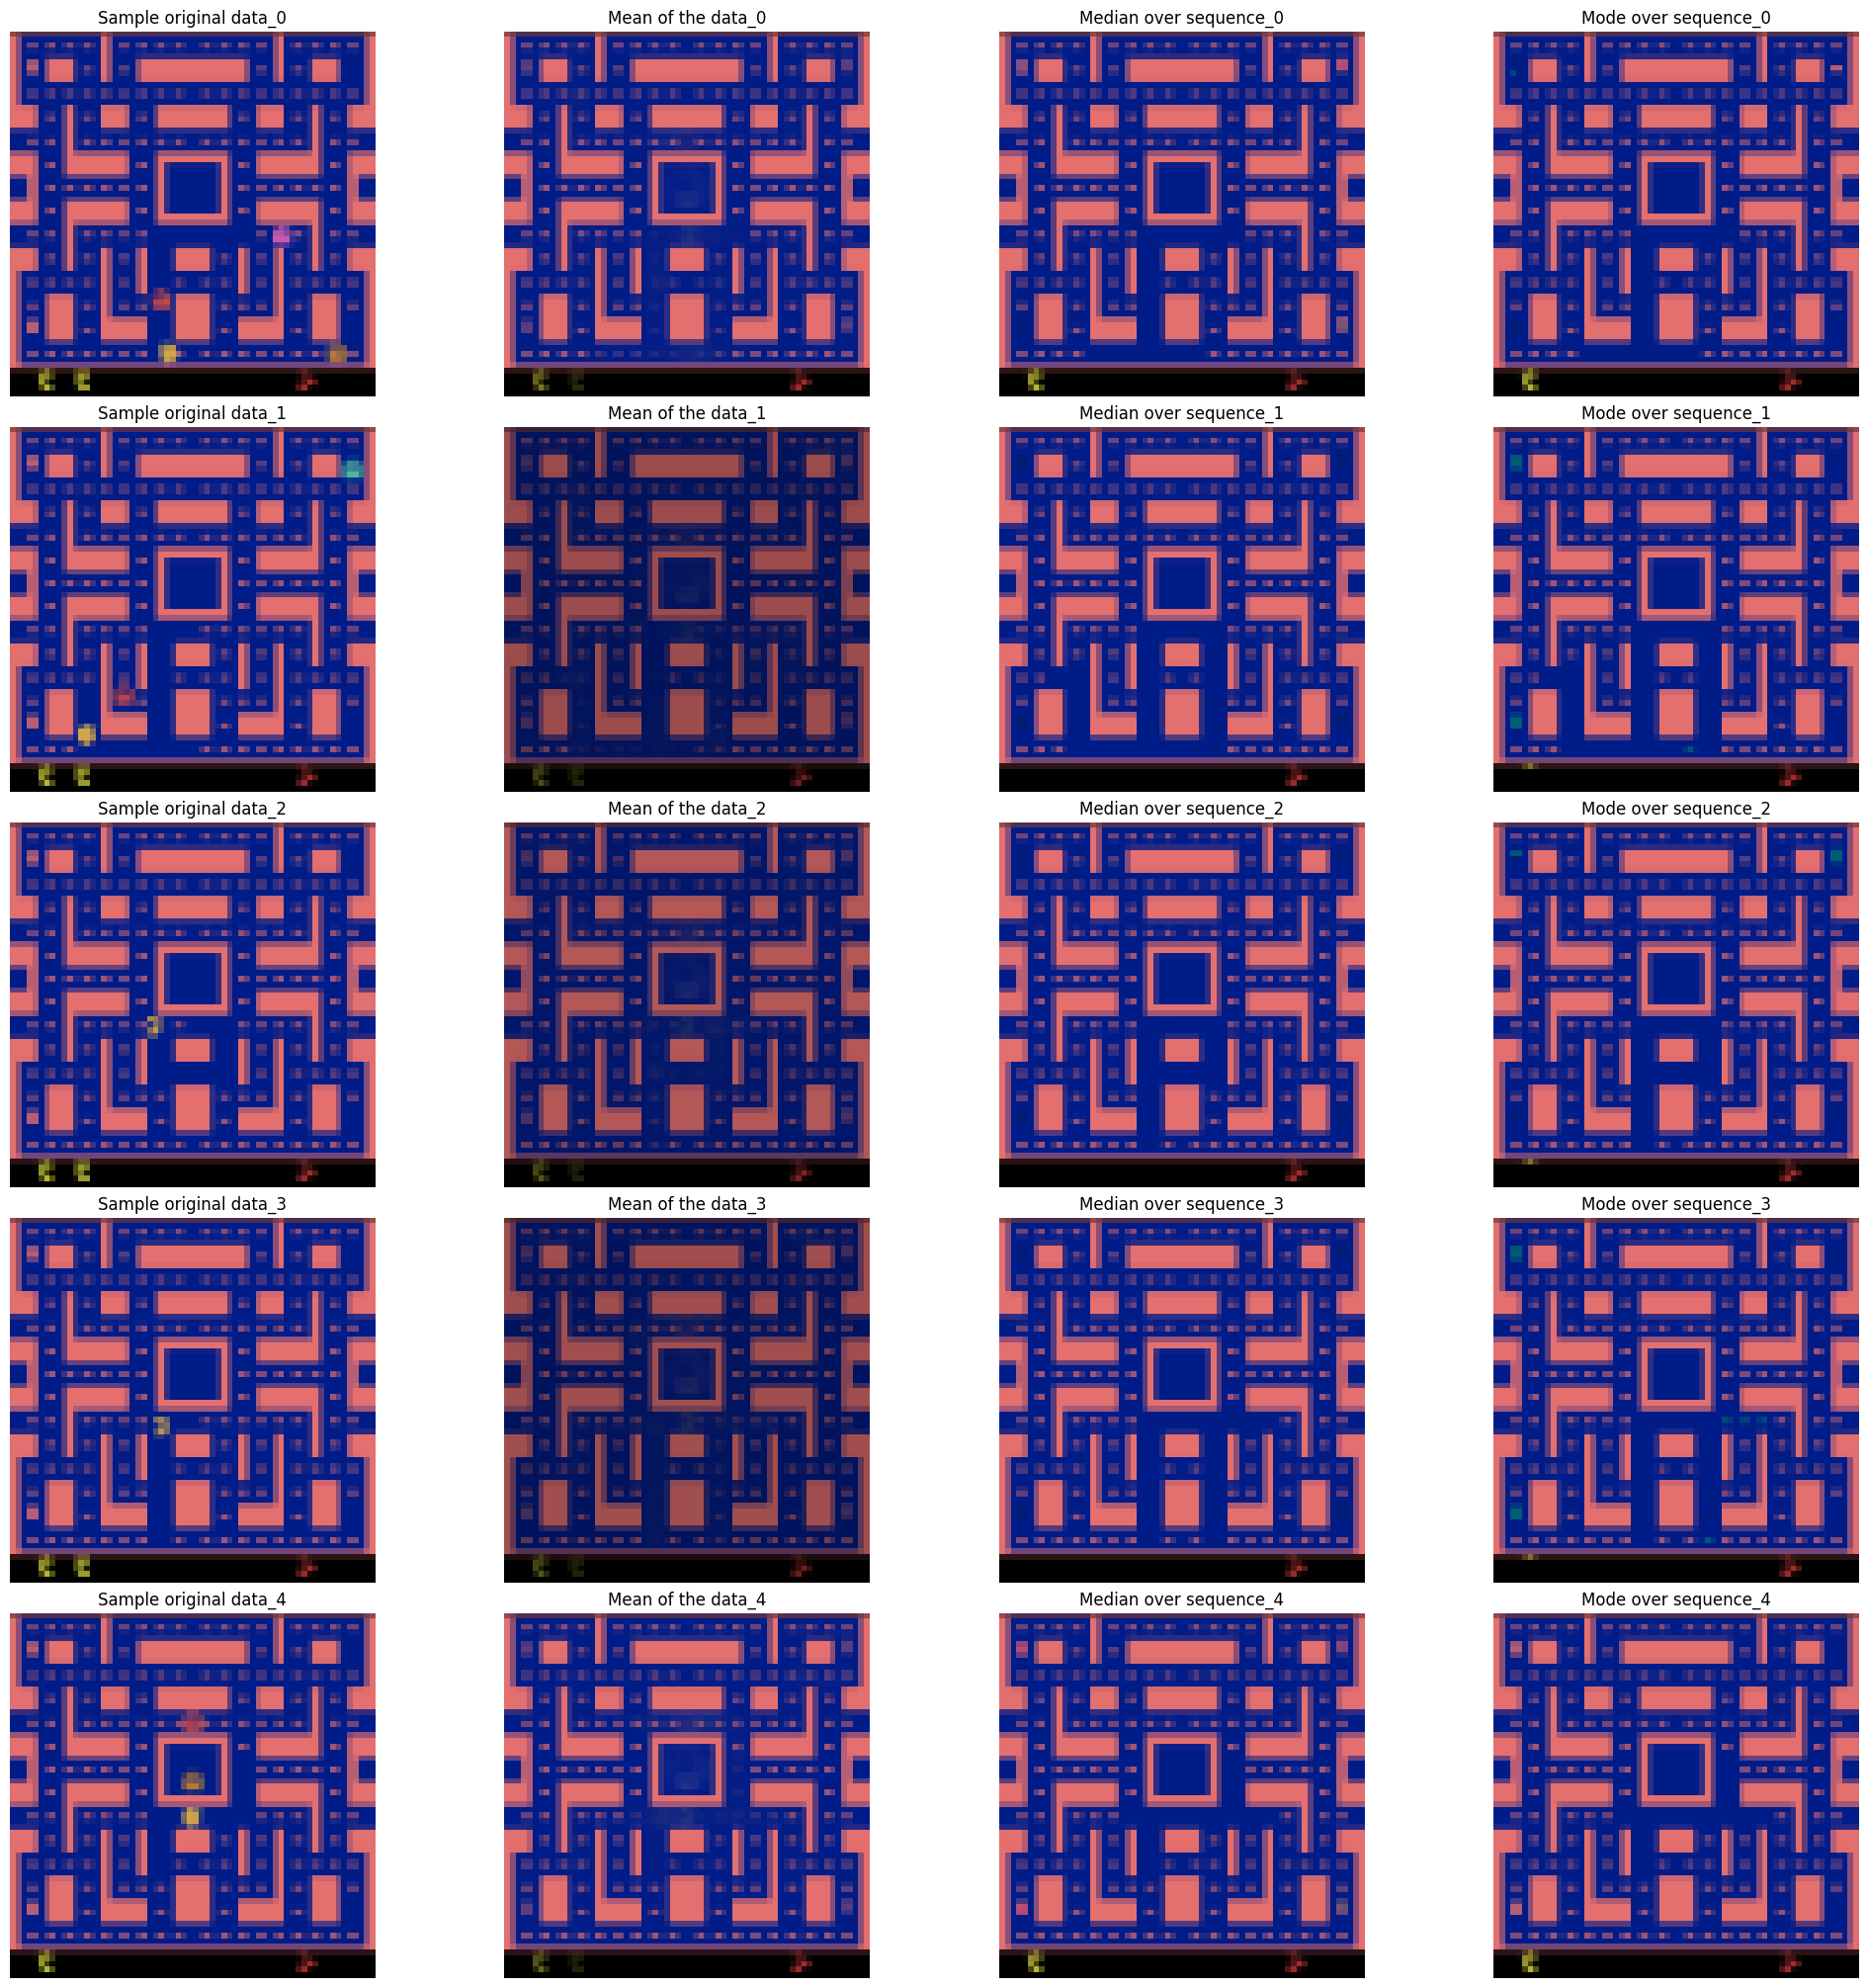

In [75]:
fig, ax = plt.subplots(5, 4, figsize=(20, 20), constrained_layout=True)

for i, batch in enumerate(dl):
    if i >= 5:
        break

    obs = batch[0]
    obs_mean = torch.mean(obs, dim=1)
    obs_median = torch.median(obs, dim=1).values
    obs_mode = torch.mode(obs, dim=1).values

    ax[i][0].set_title(f"Sample original data_{i}")
    ax[i][0].imshow(obs[0][100].permute(1, 2, 0))
    ax[i][0].axis("off")
    
    ax[i][1].set_title(f"Mean of the data_{i}")
    ax[i][1].imshow(obs_mean[0].permute(1, 2, 0))
    ax[i][1].axis("off")
    
    ax[i][2].set_title(f"Median over sequence_{i}")
    ax[i][2].imshow(obs_median[0].permute(1, 2, 0))
    ax[i][2].axis("off")
    
    ax[i][3].set_title(f"Mode over sequence_{i}")
    ax[i][3].imshow(obs_mode[0].permute(1, 2, 0))
    ax[i][3].axis("off")
    
    i += 1

plt.show()

The median one over multiple runs seems consistently the best for a representation of the background; the only issue is that of the one life and the cherry appearing on the screen.

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.24705884..0.7764706].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.4627451..0.7490196].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3411765..0.7490196].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3411765..0.7490196].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.3411765..0.7490196].


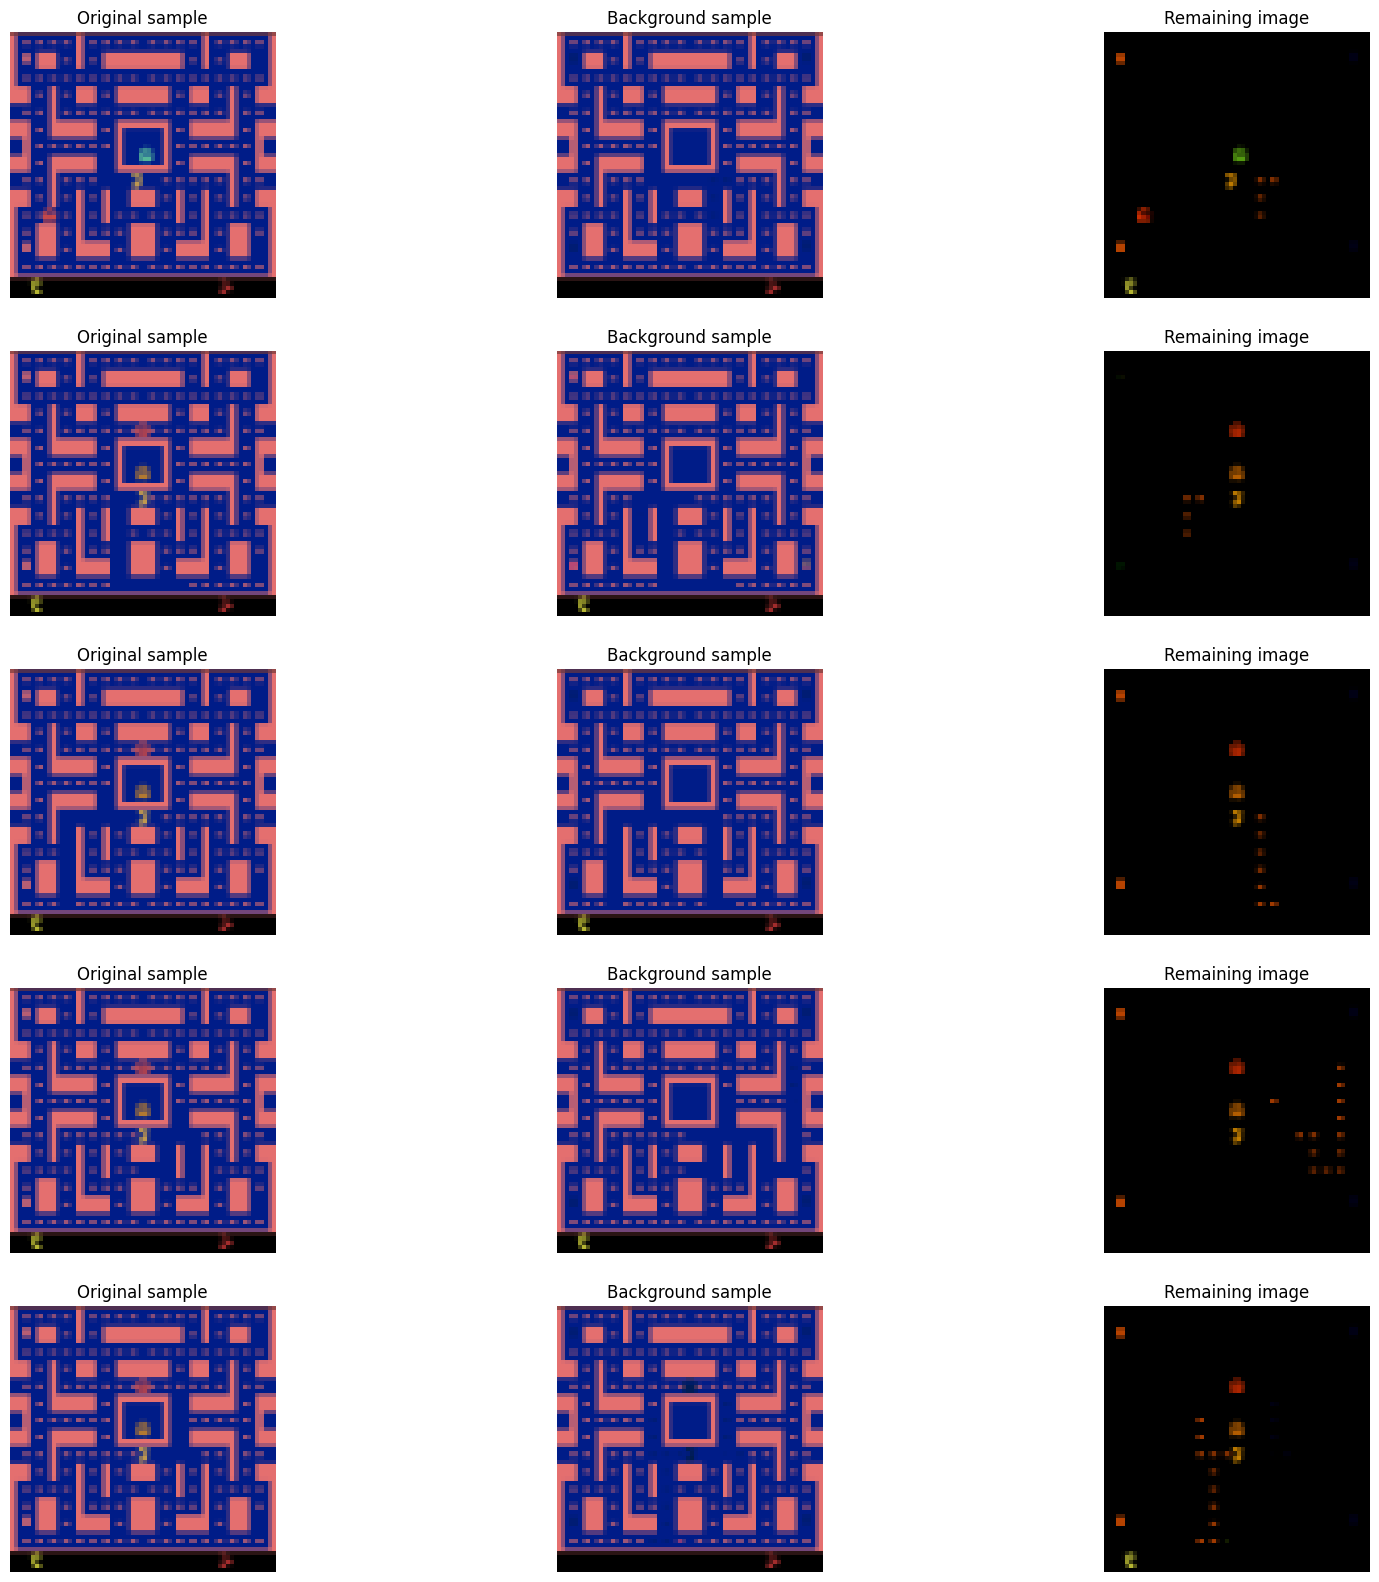

In [ ]:
fig, ax = plt.subplots(5, 3, figsize=(20, 20))

for i, batch in enumerate(dl):
    if i >= 5:
        break
    obs = batch[0]
    
    bg = torch.median(obs, dim=1).values[0]
    sample = obs[0][129]

    ax[i][0].set_title("Original sample")
    ax[i][0].imshow(sample.permute(1, 2, 0))
    ax[i][0].axis("off")

    ax[i][1].set_title("Background sample")
    ax[i][1].imshow(bg.permute(1, 2, 0))
    ax[i][1].axis("off")

    ax[i][2].set_title("Remaining image")
    ax[i][2].imshow((sample - bg).permute(1, 2, 0))
    ax[i][2].axis("off")

    i += 1